<a href="https://colab.research.google.com/github/cristian0527/MATH-383/blob/main/Final_Project_Warmup_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://github.com/cristian0527/MATH-383/blob/main/Final_Project_Warmup_1.ipynb

In [1]:
import networkx as nx
import random
import math
import matplotlib.pyplot as plt
import itertools

In [2]:
G = nx.Graph()

G.add_nodes_from([1,2,3,4])
pos =  nx.kamada_kawai_layout(G)

In [3]:
def score_uniform(G):
    return 1

def score_ERGM(G, theta_edges,theta_tri,theta_odd):

    count = 0

    for edge in G.edges():
        if edge[0] %2 == edge[1] %2:
            count += 1

    return math.exp(theta_edges*G.size() + theta_tri*sum(nx.triangles(G).values())/3 + theta_odd * count)

def graphs_equal(graph1, graph2):
    """Check if graphs are equal.

    Equality here means equal as Python objects (not isomorphism).
    Node, edge and graph data must match.

    Parameters
    ----------
    graph1, graph2 : graph

    Returns
    -------
    bool
        True if graphs are equal, False otherwise.
    """
    return (
        graph1.adj == graph2.adj
        and graph1.nodes == graph2.nodes
        and graph1.graph == graph2.graph
    )

#Empty Graph is most likely

In [5]:
#empty graph is most likely
all_edges = list(itertools.combinations([1,2,3,4], 2))


scores_empty = []
networks = []
for choices in list(itertools.product([0, 1], repeat=6)):
    G = nx.Graph()
    G.add_nodes_from([1,2,3,4])
    for i in range(6):
        if choices[i] == 1:
            G.add_edge(all_edges[i][0],all_edges[i][1])

    scores_empty.append(score_ERGM(G, -.7,-.5,.5))
    networks.append(G)

all_scores_empty = sum(scores_empty)

In [6]:
#sampling 20000 networks
G = nx.Graph()
G.add_nodes_from([1,2,3,4])

nlist = list(G.nodes())
triangles = []
num_edges = []
parity = []
net_count = [0 for x in range(64)]

for step in range(20000):
    end_points = random.sample(nlist,k=2)

    G_hat = G.copy()

    if (end_points[0],end_points[1]) in G_hat.edges() or (end_points[1],end_points[0]) in G_hat.edges():
        G_hat.remove_edge(end_points[0],end_points[1])

    else:
        G_hat.add_edge(end_points[0],end_points[1])

    alpha = min(1, score_ERGM(G_hat, -.7,-.5,.5)/score_ERGM(G_hat, -.7,-.5,.5))

    if random.random() < alpha:
        G = G_hat
    else:
        pass

    triangles.append(sum(nx.triangles(G).values())/3)
    num_edges.append(len(list(G.edges())))

    count = 0

    for edge in G.edges():
        if edge[0] %2 == edge[1] %2:
            count += 1

    parity.append(count)

    for i in range(64):
        if graphs_equal(G,networks[i]):
            net_count[i] += 1

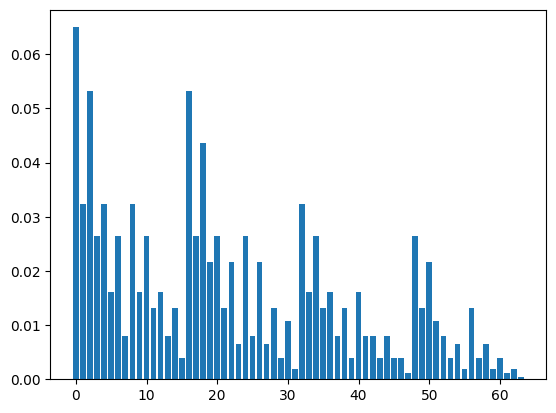

<BarContainer object of 64 artists>

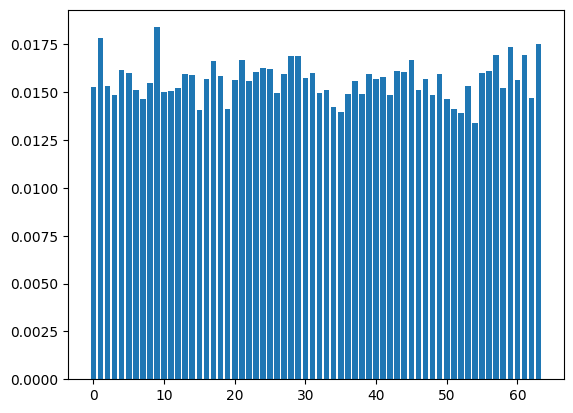

In [7]:
#scores for empty graph
scores_vec_empty=[x/all_scores_empty for x in scores_empty]
sample_vec = [x/20000 for x in net_count]
plt.bar(range(64),scores_vec_empty)
plt.show()
plt.bar(range(64),sample_vec)

#Full graph is most likely

In [8]:
#full graph is most likely
all_edges = list(itertools.combinations([1,2,3,4], 2))


scores_full = []
networks = []
for choices in list(itertools.product([0, 1], repeat=6)):
    G = nx.Graph()
    G.add_nodes_from([1,2,3,4])
    for i in range(6):
        if choices[i] == 1:
            G.add_edge(all_edges[i][0],all_edges[i][1])

    scores_full.append(score_ERGM(G, .5,.4,.1))
    networks.append(G)

all_scores_full = sum(scores_full)

In [9]:
#sampling 20000 networks
G = nx.Graph()
G.add_nodes_from([1,2,3,4])

nlist = list(G.nodes())
triangles = []
num_edges = []
parity = []
net_count = [0 for x in range(64)]

for step in range(20000):
    end_points = random.sample(nlist,k=2)

    G_hat = G.copy()

    if (end_points[0],end_points[1]) in G_hat.edges() or (end_points[1],end_points[0]) in G_hat.edges():
        G_hat.remove_edge(end_points[0],end_points[1])

    else:
        G_hat.add_edge(end_points[0],end_points[1])

    alpha = min(1, score_ERGM(G_hat, .5,.4,.1)/score_ERGM(G_hat, .5,.4,.1))

    if random.random() < alpha:
        G = G_hat
    else:
        pass

    triangles.append(sum(nx.triangles(G).values())/3)
    num_edges.append(len(list(G.edges())))

    count = 0

    for edge in G.edges():
        if edge[0] %2 == edge[1] %2:
            count += 1

    parity.append(count)

    for i in range(64):
        if graphs_equal(G,networks[i]):
            net_count[i] += 1

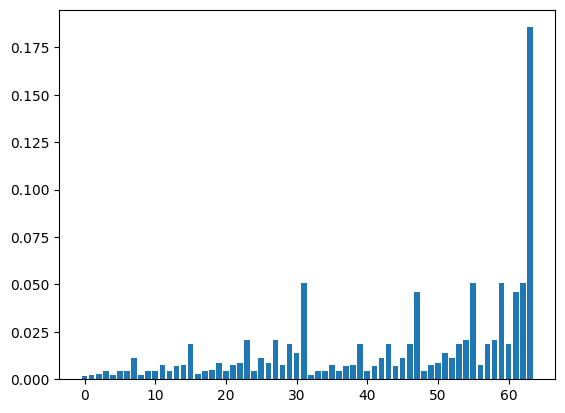

<BarContainer object of 64 artists>

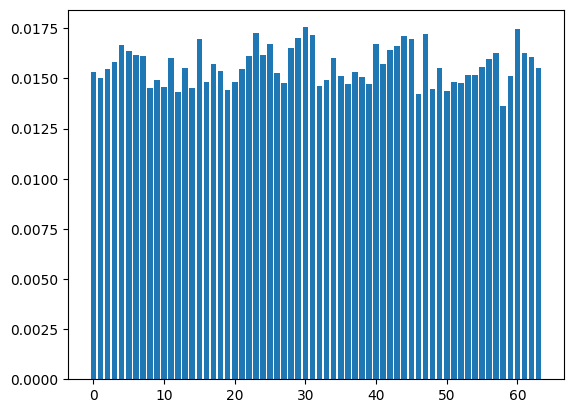

In [10]:
#scores for full graph
scores_vec_full=[x/all_scores_full for x in scores_full]
sample_vec = [x/20000 for x in net_count]
plt.bar(range(64),scores_vec_full)
plt.show()
plt.bar(range(64),sample_vec)

#Partial Graph is most likely

In [11]:
#partial graph is most likely
all_edges = list(itertools.combinations([1,2,3,4], 2))


scores_partial = []
networks = []
for choices in list(itertools.product([0, 1], repeat=6)):
    G = nx.Graph()
    G.add_nodes_from([1,2,3,4])
    for i in range(6):
        if choices[i] == 1:
            G.add_edge(all_edges[i][0],all_edges[i][1])

    scores_partial.append(score_ERGM(G, .5,-.5,.2))
    networks.append(G)

all_scores_partial = sum(scores_partial)

In [12]:
#sampling 20000 networks
G = nx.Graph()
G.add_nodes_from([1,2,3,4])

nlist = list(G.nodes())
triangles = []
num_edges = []
parity = []
net_count = [0 for x in range(64)]

for step in range(20000):
    end_points = random.sample(nlist,k=2)

    G_hat = G.copy()

    if (end_points[0],end_points[1]) in G_hat.edges() or (end_points[1],end_points[0]) in G_hat.edges():
        G_hat.remove_edge(end_points[0],end_points[1])

    else:
        G_hat.add_edge(end_points[0],end_points[1])

    alpha = min(1, score_ERGM(G_hat, .5,-.5,.2)/score_ERGM(G_hat, .5,-.5,.2))

    if random.random() < alpha:
        G = G_hat
    else:
        pass

    triangles.append(sum(nx.triangles(G).values())/3)
    num_edges.append(len(list(G.edges())))

    count = 0

    for edge in G.edges():
        if edge[0] %2 == edge[1] %2:
            count += 1

    parity.append(count)

    for i in range(64):
        if graphs_equal(G,networks[i]):
            net_count[i] += 1

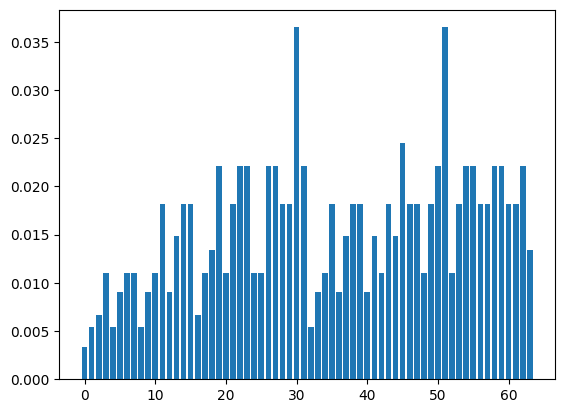

<BarContainer object of 64 artists>

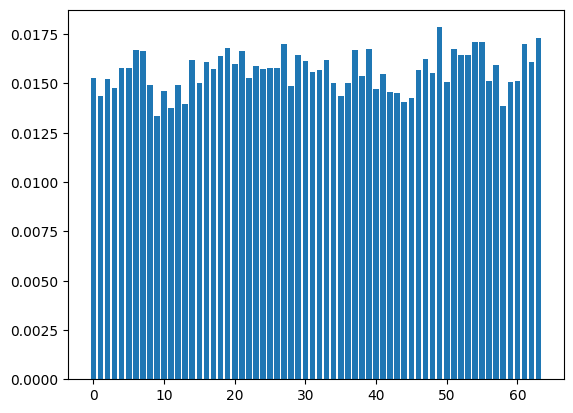

In [13]:
#scores for empty graph
#scores for full graph
scores_vec_partial=[x/all_scores_partial for x in scores_partial]
sample_vec = [x/20000 for x in net_count]
plt.bar(range(64),scores_vec_partial)
plt.show()
plt.bar(range(64),sample_vec)

In [ ]:
#question 4
#center, skewness, variance, stdev, expected value

In [14]:
import numpy as np
print(np.var(scores_vec_empty))
print(np.var(scores_vec_full))
print(np.var(scores_vec_partial))

0.00018344919666905398
0.0006251963089058646
4.42114271935906e-05


In [15]:
print(np.std(scores_vec_empty))
print(np.std(scores_vec_full))
print(np.std(scores_vec_partial))

0.013544341869173783
0.02500392586986821
0.0066491674060434516


In [16]:
indeces = range(0,64)
def ev(values, scores):
    values = np.asarray(values)
    return (values * scores).sum() / scores.sum()

print(ev(indeces,np.asarray(scores_vec_empty)))
print(ev(indeces,np.asarray(scores_vec_full)))
print(ev(indeces,np.asarray(scores_vec_partial)))

21.55521218938196
45.2247678779971
35.37835862121


- The first graph has a clear mode of 0, though it has a secondary mode at 17. It is right-skewed. It has a variance of 0.00019, standard deviation of 0.0135, and expected value of 21.555.

- The second graph has a mode of 64 and is left-skewed. It has a variance of 0.0006, the highest of the three distributions. It has a standard deviation of 0.025 and an expected value of 25.225.

- The third graph is bimodal, with modes of 52 and 31 (which are both graphs with 4 nodes and 4 edges), and is slightly left-skewed. It has a variance of 4.42e-05, the lowest of the three distribution. It has a standard deviation of 0.0066 and an expected value of 35.378.

#Part 2

0.9048374180359596

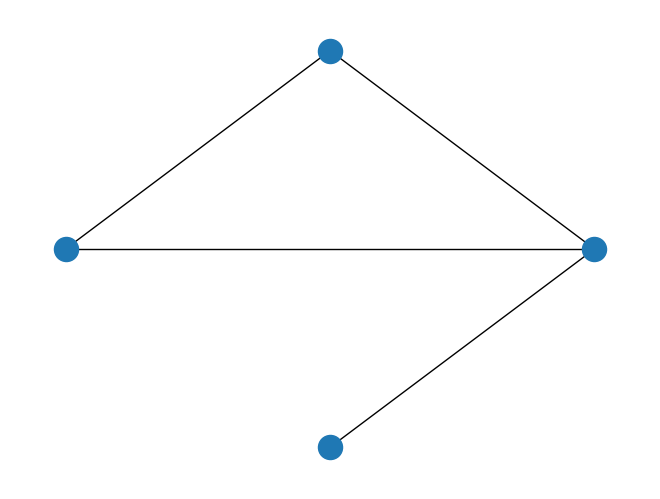

In [17]:
# MCMC- MLE

target = nx.Graph()
#index 60 in networks list

target.add_nodes_from([1,2,3,4])
target.add_edges_from([(1,2),(1,3),(1,4),(2,3)])

nx.draw(target,pos=pos)

#initial guess
theta_edges=-.2
theta_tri=.2
theta_odd = .5


score_ERGM(target, theta_edges,theta_tri,theta_odd)

# in this case g(y) = (4,1,1)


In [18]:
def target_mcmc(target,steps,burn,thin, theta_edges,theta_tri,theta_odd):
    G = nx.Graph()
    G.add_nodes_from([1,2,3,4])

    nlist = list(G.nodes())
    triangles = []
    num_edges = []
    parity = []

    t_edges = target.size()
    t_tri = sum(nx.triangles(target).values())/3

    count = 0

    for edge in target.edges():
        if edge[0] %2 == edge[1] %2:
            count += 1

    t_odd = count


    for step in range(steps):
        end_points = random.sample(nlist,k=2)

        G_hat = G.copy()

        if (end_points[0],end_points[1]) in G_hat.edges() or (end_points[1],end_points[0]) in G_hat.edges():
            G_hat.remove_edge(end_points[0],end_points[1])

        else:
            G_hat.add_edge(end_points[0],end_points[1])

        alpha = min(1, score_ERGM(G_hat, theta_edges,theta_tri,theta_odd)
    /score_ERGM(G, theta_edges,theta_tri,theta_odd)
    )

        if random.random() < alpha:
            G = G_hat
        else:
            pass

        if step >= burn and step%thin == 0:
            triangles.append(sum(nx.triangles(G).values())/3)
            num_edges.append(len(list(G.edges())))

            count = 0

            for edge in G.edges():
                if edge[0] %2 == edge[1] %2:
                    count += 1

            parity.append(count)



    #compare MCMC statistics to g(y)
    print(sum(num_edges)/((steps-burn)/thin) - t_edges)
    print(sum(triangles)/((steps-burn)/thin) - t_tri)
    print(sum(parity)/((steps-burn)/thin) - t_odd)

    return sum(num_edges)/((steps-burn)/thin) - t_edges, sum(triangles)/((steps-burn)/thin) - t_tri, sum(parity)/((steps-burn)/thin) - t_odd

In [19]:
#question 1: minimizing theta parameters
a,b,c = target_mcmc(target,20000,1000,1, 0.751,-0.25,0.2)
abs(a) + abs(b) + abs(c)

-0.10547368421052639
0.0189473684210526
0.3596315789473685


0.4840526315789475

In [20]:
#question 2: minimizing steps, burn, and thin
a,b,c = target_mcmc(target,20000,200,1, 0.751,-0.25,0.2)
abs(a) + abs(b) + abs(c)

-0.14742424242424246
-0.013030303030303059
0.3303030303030303


0.49075757575757584

In [22]:
#question 3:
all_edges = list(itertools.combinations([1,2,3,4], 2))


scores_23 = []
networks = []
for choices in list(itertools.product([0, 1], repeat=6)):
    G = nx.Graph()
    G.add_nodes_from([1,2,3,4])
    for i in range(6):
        if choices[i] == 1:
            G.add_edge(all_edges[i][0],all_edges[i][1])

    scores_23.append(score_ERGM(G, 0.751,-0.25,0.2))
    networks.append(G)

all_scores_23 = sum(scores_23)

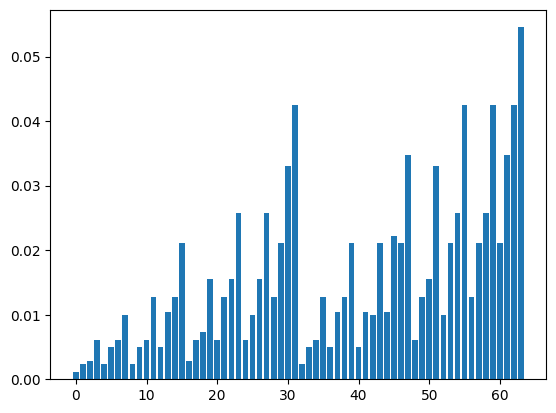

In [ ]:
scores_23_vec=[x/all_scores_23 for x in scores_23]
plt.bar(range(64),scores_23_vec)
plt.show()